Saving superstore.csv to superstore (2).csv

Shape: (51290, 27)
          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  è®°å½æ°               Order.Date        Order.ID  ...  \
0       0.0     US          1  2011-01-07 00:00:00.000  CA-2011-130813  ...   
1       0.0     US          1  2011-01-21 00:00:00.000  CA-2011-148614  ...   
2       0.0     US          1  2011-08-05 00:00:00.000  CA-2011-118962  ...   
3       0.0     US          1  2011-08-05 00:00:00.000  CA-2011-118962  ...   
4       0.0     US          1  2011-09-29 00:00:00.000  CA-2

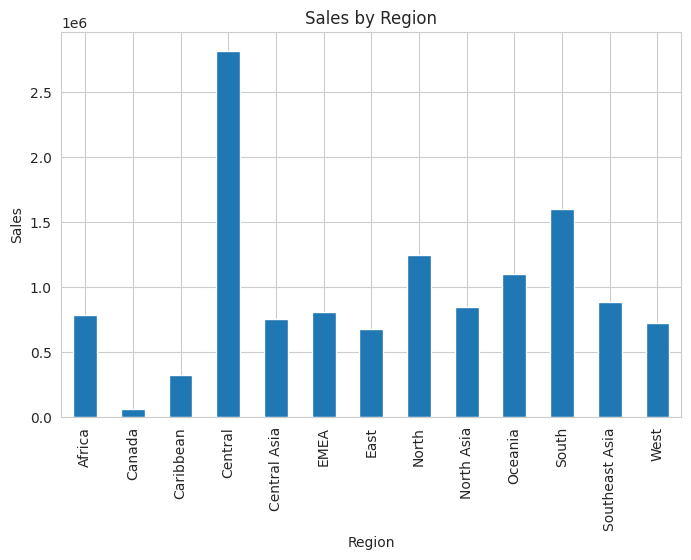

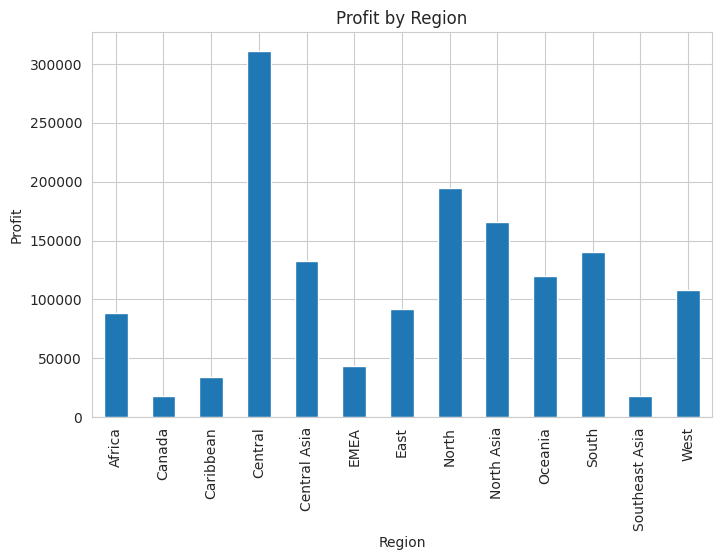

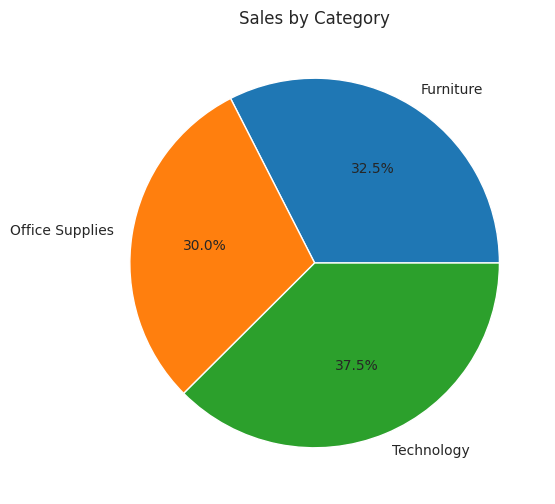

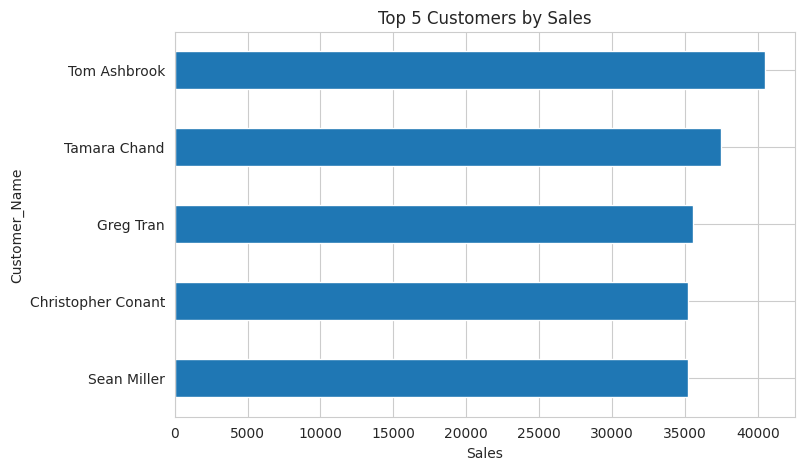

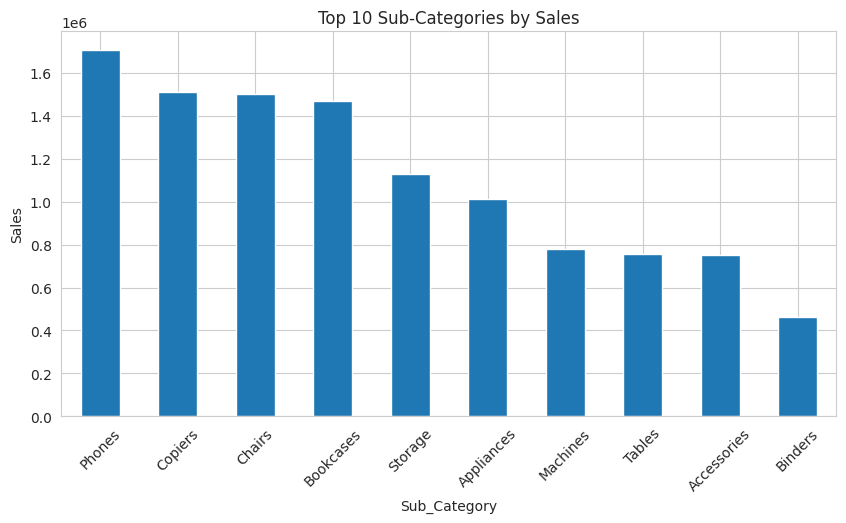


================= CONCLUSION =================

This business analytics dashboard provides insights into:

- Total Sales and Profit
- Regional Performance
- Top Customers
- Product Category Performance
- Sub-Category Trends

These insights help in strategic decision-making
for improving revenue and profitability.




In [3]:
# ==========================================================
# TASK 5: BUSINESS INTELLIGENCE DASHBOARD (COLAB VERSION)
# FIXED FOR YOUR DATASET STRUCTURE
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set_style("whitegrid")

# ==========================================================
# UPLOAD DATASET
# ==========================================================

uploaded = files.upload()

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("superstore.csv", encoding="latin1")

print("\nShape:", df.shape)
print(df.head())

# ==========================================================
# CLEAN COLUMN NAMES (IMPORTANT FIX)
# ==========================================================

df.columns = (
    df.columns
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print("\nCLEANED COLUMNS:")
print(df.columns.tolist())

# ==========================================================
# DATA CLEANING
# ==========================================================

print("\nMissing Values:")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("\nShape after removing duplicates:", df.shape)

# ==========================================================
# KPI CALCULATIONS
# ==========================================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()

print("\n========== KPIs ==========")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")

# ==========================================================
# TOP 5 CUSTOMERS
# ==========================================================

top_customers = (
    df.groupby("Customer_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 Customers:")
print(top_customers)

# ==========================================================
# SALES BY REGION
# ==========================================================

sales_region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_region.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

# ==========================================================
# PROFIT BY REGION
# ==========================================================

profit_region = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))
profit_region.plot(kind="bar")
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()

# ==========================================================
# SALES BY CATEGORY
# ==========================================================

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(6,6))
category_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Category")
plt.ylabel("")
plt.show()

# ==========================================================
# TOP 5 CUSTOMERS CHART
# ==========================================================

plt.figure(figsize=(8,5))
top_customers.sort_values().plot(kind="barh")
plt.title("Top 5 Customers by Sales")
plt.xlabel("Sales")
plt.show()

# ==========================================================
# TOP 10 SUB-CATEGORIES
# ==========================================================

subcat_sales = (
    df.groupby("Sub_Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
subcat_sales.plot(kind="bar")
plt.title("Top 10 Sub-Categories by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# REGION FILTER EXAMPLE
# ==========================================================

if "Asia_Pacific" in df["Market2"].values:

    asia_sales = df[df["Market2"] == "Asia_Pacific"]["Sales"].sum()

    print("\nAsia Pacific Sales:", asia_sales)

# ==========================================================
# FINAL CONCLUSION
# ==========================================================

print("""
================= CONCLUSION =================

This business analytics dashboard provides insights into:

- Total Sales and Profit
- Regional Performance
- Top Customers
- Product Category Performance
- Sub-Category Trends

These insights help in strategic decision-making
for improving revenue and profitability.

==============================================
""")